In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [53]:
class PatchEmbedding(nn.Module):

    def __init__(
        self,
        image_size,
        patch_size,
        in_channels,
        embed_dim
    ):

        super().__init__()

        self.projection = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):

        x = self.projection(x)

        x = x.flatten(2)

        x = x.transpose(1, 2)

        return x

In [54]:
class TransformerEncoder(nn.Module):

    def __init__(
        self,
        embed_dim,
        num_heads,
        mlp_dim
    ):

        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim)
        )

    def forward(self, x):

        residual = x

        x = self.norm1(x)

        x = self.attention(x, x, x)[0]

        x = x + residual

        residual = x

        x = self.norm2(x)

        x = self.mlp(x)

        x = x + residual

        return x

In [55]:
class VisionTransformer(nn.Module):

    def __init__(
        self,
        image_size,
        patch_size,
        in_channels,
        embed_dim,
        num_heads,
        mlp_dim,
        num_layers
    ):

        super().__init__()

        self.patch_embedding = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = (image_size // patch_size) ** 2

        self.cls_token = nn.Parameter(
            torch.randn(1, 1, embed_dim)
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, embed_dim)
        )

        self.transformer_blocks = nn.Sequential(
            *[
                TransformerEncoder(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    mlp_dim=mlp_dim
                )
                for _ in range(num_layers)
            ]
        )

    def forward(self,x):

      x = self.patch_embedding(x)

      batch_size = x.shape[0]

      cls_token = self.cls_token.expand(batch_size, -1, -1)

      x = torch.cat((cls_token, x), dim=1)

      x = x + self.pos_embedding

      x = self.transformer_blocks(x)

      x = x[:, 0]

      return x

In [56]:
class DINOHead(nn.Module):
  def __init__(self, in_dim=768, hidden_dim=2048, bottleneck_dim = 256, out_dim=65536):
    super().__init__()

    self.mlp = nn.Sequential(
        nn.Linear(in_dim, hidden_dim),
        nn.GELU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.GELU(),
        nn.Linear(hidden_dim,bottleneck_dim)
    )

    self.last_layer = nn.utils.weight_norm(nn.Linear(bottleneck_dim,out_dim,bias=False))

  def forward(self,x):

    x=self.mlp(x)

    x=F.normalize(x,dim=-1)

    x=self.last_layer(x)

    return x

In [57]:
class StudentNetwork(nn.Module):
  def __init__(self, backbone, head):
    super().__init__()

    self.backbone = backbone
    self.head = head

  def forward(self, x):
    x = self.backbone(x)
    x = self.head(x)
    return x

In [58]:
class TeacherNetwork(nn.Module):

    def __init__(
        self,
        backbone,
        head
    ):

        super().__init__()

        self.backbone = backbone
        self.head = head

    def forward(self, x):

        x = self.backbone(x)

        x = self.head(x)

        return x

In [59]:
@torch.no_grad()
def update_teacher(student, teacher, momentum):

    for student_param, teacher_param in zip(
        student.parameters(),
        teacher.parameters()
    ):

        teacher_param.data = (
            momentum * teacher_param.data
            + (1 - momentum) * student_param.data
        )

In [60]:
class DINOLoss(nn.Module):

    def __init__(
        self,
        student_temp=0.1,
        teacher_temp=0.04
    ):
        super().__init__()

        self.student_temp = student_temp
        self.teacher_temp = teacher_temp

    def forward(
        self,
        student_output,
        teacher_output
    ):

        teacher_probs = F.softmax(
            teacher_output / self.teacher_temp,
            dim=-1
        )

        student_log_probs = F.log_softmax(
            student_output / self.student_temp,
            dim=-1
        )

        loss = -(teacher_probs * student_log_probs).sum(dim=-1)

        loss = loss.mean()

        return loss


In [61]:
# -----------------------------
# Create Student
# -----------------------------

student_backbone = VisionTransformer(
    image_size=224,
    patch_size=16,
    in_channels=3,
    embed_dim=768,
    num_heads=12,
    mlp_dim=3072,
    num_layers=12
)

student_head = DINOHead()

student = StudentNetwork(
    student_backbone,
    student_head
)


# -----------------------------
# Create Teacher
# -----------------------------

teacher_backbone = VisionTransformer(
    image_size=224,
    patch_size=16,
    in_channels=3,
    embed_dim=768,
    num_heads=12,
    mlp_dim=3072,
    num_layers=12
)

teacher_head = DINOHead()

teacher = TeacherNetwork(
    teacher_backbone,
    teacher_head
)


# Teacher starts with Student weights
teacher.load_state_dict(student.state_dict())


# Freeze Teacher
for param in teacher.parameters():
    param.requires_grad = False

In [62]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.CIFAR10(
    root="/content/drive/MyDrive/Datasets/CIFAR10",   # or "./data" if local
    train=True,
    download=True,
    transform=transform
)

small_dataset = Subset(
    dataset,
    range(2000)
)



In [63]:
dataloader = DataLoader(
    small_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Dataset Size:", len(small_dataset))

Dataset Size: 2000


In [64]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

student.to(device)
teacher.to(device)

TeacherNetwork(
  (backbone): VisionTransformer(
    (patch_embedding): PatchEmbedding(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (transformer_blocks): Sequential(
      (0): TransformerEncoder(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (1): TransformerEncoder(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
    

In [65]:
criterion = DINOLoss()

optimizer = torch.optim.Adam(
    student.parameters(),
    lr=1e-4)

In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

student.to(device)
teacher.to(device)

num_epochs = 10

train_losses = []

for epoch in range(num_epochs):

    student.train()
    teacher.eval()

    epoch_loss = 0.0

    for images, _ in dataloader:

        images = images.to(device)

        student_output = student(images)

        with torch.no_grad():
            teacher_output = teacher(images)

        loss = criterion(student_output, teacher_output)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        update_teacher(student, teacher, momentum=0.996)

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)

    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

Epoch [1/10] Average Loss: 10.6935
Epoch [2/10] Average Loss: 10.3622
Epoch [3/10] Average Loss: 9.8120
Epoch [4/10] Average Loss: 8.9093
Epoch [5/10] Average Loss: 7.5517
Epoch [6/10] Average Loss: 5.8377
Epoch [7/10] Average Loss: 4.1798
Epoch [8/10] Average Loss: 2.9270
Epoch [9/10] Average Loss: 2.0917
Epoch [10/10] Average Loss: 1.5303


In [67]:
torch.save(student.state_dict(), "student_dino_minimal.pth")
torch.save(teacher.state_dict(), "teacher_dino_minimal.pth")

print("Student and Teacher models saved successfully!")

Student and Teacher models saved successfully!


In [68]:
import pandas as pd

loss_df = pd.DataFrame({
    "Epoch": range(1, num_epochs + 1),
    "Loss": train_losses
})

loss_df.to_csv("training_loss.csv", index=False)

print(loss_df)

   Epoch       Loss
0      1  10.693539
1      2  10.362219
2      3   9.811982
3      4   8.909315
4      5   7.551721
5      6   5.837675
6      7   4.179756
7      8   2.927029
8      9   2.091680
9     10   1.530295


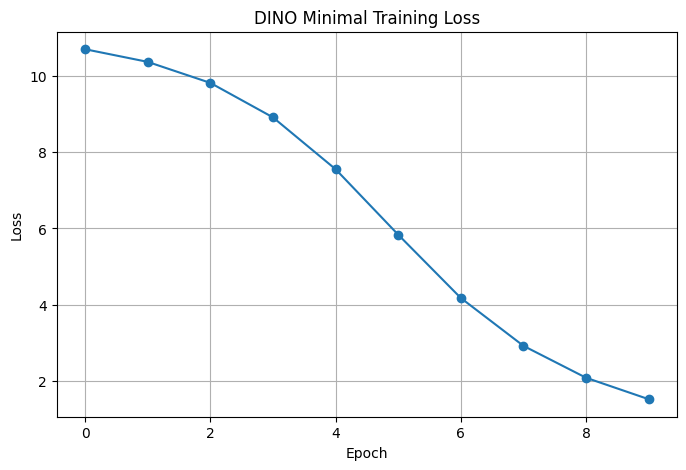

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')

plt.title("DINO Minimal Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [74]:
new_student_backbone = VisionTransformer(
    image_size=224,
    patch_size=16,
    in_channels=3,
    embed_dim=768,
    num_heads=12,
    mlp_dim=3072,
    num_layers=12
)

new_student_head = DINOHead()

new_student = StudentNetwork(
    new_student_backbone,
    new_student_head
).to(device)

new_student.load_state_dict(torch.load("student_dino_minimal.pth"))

new_student.eval()

print("Student model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Student model loaded successfully!
